In [ ]:
#Importo librerias
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
#Leer los datos excell
fich = "exa1.xlsx"
df = pd.read_excel(fich)
df

,AÑONAC,ESTADO,ALCOHOL,DROGAS,POBLACION,PROVINCIA,ENFERMEDAD
0,2001,SOLTERO,SI,NO,CORIA,CACERES,0.13
1,2003,CASADO,SI,SI,MORALEJA,CACERES,0.90
2,2004,SEPARADO,SI,NO,GATA,CACERES,0.85
3,2001,PAREJAHECHO,NO,SI,HOYOS,CACERES,0.25
4,2002,CASADO,SI,NO,PERALES,CACERES,0.01
5,1999,SOLTERO,NO,SI,CACERES,CACERES,1.00
6,2010,SOLTERO,NO,NO,CORIA,CACERES,0.75
7,1980,SEPARADO,SI,NO,PERALES,CACERES,0.68
8,1995,CASADO,NO,NO,MORALEJA,CACERES,0.27
9,1987,CASADO,NO,NO,HOYOS,CACERES,0.37


In [ ]:
#1.1
#Filas
df.shape[0]

16

In [ ]:
#Columnas
df.shape[1]

7

In [ ]:
#Nombre de las columnas
df.columns

Index(['AÑONAC', 'ESTADO', 'ALCOHOL', 'DROGAS', 'POBLACION', 'PROVINCIA',
       'ENFERMEDAD'],
      dtype='object')

In [ ]:
#1.3
#Tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   AÑONAC      16 non-null     int64  
 1   ESTADO      16 non-null     object 
 2   ALCOHOL     16 non-null     object 
 3   DROGAS      16 non-null     object 
 4   POBLACION   16 non-null     object 
 5   PROVINCIA   16 non-null     object 
 6   ENFERMEDAD  16 non-null     float64
dtypes: float64(1), int64(1), object(5)
memory usage: 1.0+ KB


In [ ]:
#Numero de celdas del df
df.size

112

In [ ]:
#1.4
#Pasar object a categoricas
df['ESTADO'] = pd.Categorical(df['ESTADO'])
df['ALCOHOL'] = pd.Categorical(df['ALCOHOL'])
df['DROGAS'] = pd.Categorical(df['DROGAS'])
df['POBLACION'] = pd.Categorical(df['POBLACION'])
df['PROVINCIA'] = pd.Categorical(df['PROVINCIA'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   AÑONAC      16 non-null     int64   
 1   ESTADO      16 non-null     category
 2   ALCOHOL     16 non-null     category
 3   DROGAS      16 non-null     category
 4   POBLACION   16 non-null     category
 5   PROVINCIA   16 non-null     category
 6   ENFERMEDAD  16 non-null     float64 
dtypes: category(5), float64(1), int64(1)
memory usage: 1.4 KB


In [ ]:
#1.5
#Columnas dummies
alcohol_dummy = pd.get_dummies(df['ALCOHOL'], prefix='ALCOHOL')
df = pd.concat([df, alcohol_dummy], axis=1)
df = df.drop(['ALCOHOL'], axis = 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   AÑONAC      16 non-null     int64   
 1   ESTADO      16 non-null     category
 2   DROGAS      16 non-null     category
 3   POBLACION   16 non-null     category
 4   PROVINCIA   16 non-null     category
 5   ENFERMEDAD  16 non-null     float64 
 6   ALCOHOL_NO  16 non-null     bool    
 7   ALCOHOL_SI  16 non-null     bool    
dtypes: bool(2), category(4), float64(1), int64(1)
memory usage: 1.3 KB


In [ ]:
#1.6
#Pasar a categorica las 2 nuevas de alcochol
df['ALCOHOL_NO'] = pd.Categorical(df['ALCOHOL_NO'])
df['ALCOHOL_SI'] = pd.Categorical(df['ALCOHOL_SI'])
#Cat codes
df['ESTADO'] = df['ESTADO'].cat.codes
df['DROGAS'] = df['DROGAS'].cat.codes
df['POBLACION'] = df['POBLACION'].cat.codes
df['PROVINCIA'] = df['PROVINCIA'].cat.codes
df['ALCOHOL_NO'] = df['ALCOHOL_NO'].cat.codes
df['ALCOHOL_SI'] = df['ALCOHOL_SI'].cat.codes
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   AÑONAC      16 non-null     int64  
 1   ESTADO      16 non-null     int8   
 2   DROGAS      16 non-null     int8   
 3   POBLACION   16 non-null     int8   
 4   PROVINCIA   16 non-null     int8   
 5   ENFERMEDAD  16 non-null     float64
 6   ALCOHOL_NO  16 non-null     int8   
 7   ALCOHOL_SI  16 non-null     int8   
dtypes: float64(1), int64(1), int8(6)
memory usage: 480.0 bytes


,AÑONAC,ESTADO,DROGAS,POBLACION,PROVINCIA,ENFERMEDAD,ALCOHOL_NO,ALCOHOL_SI
0,2001,3,1,1,1,0.13,0,1
1,2003,0,2,5,1,0.90,0,1
2,2004,2,1,2,1,0.85,0,1
3,2001,1,2,3,1,0.25,1,0
4,2002,0,1,6,1,0.01,0,1
5,1999,3,2,0,1,1.00,1,0
6,2010,3,1,1,1,0.75,1,0
7,1980,2,1,6,1,0.68,0,1
8,1995,0,1,5,1,0.27,1,0
9,1987,0,1,3,1,0.37,1,0


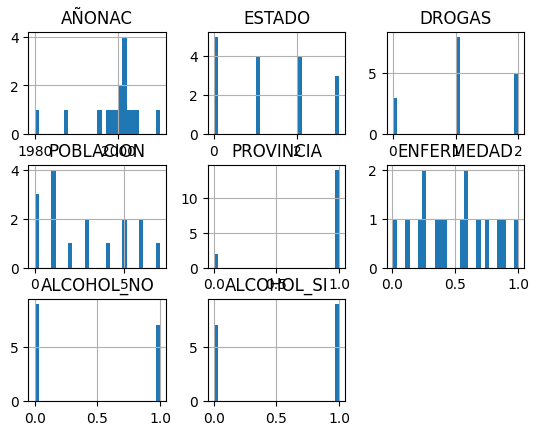

In [ ]:
#1.7
hist = df.hist(bins=30)

In [ ]:
#1.8
#Dividir el df en X e Y
X = df.drop('ENFERMEDAD', axis=1)
Y = df["ENFERMEDAD"]

In [ ]:
#1.9
#Normalizar X
scaler = StandardScaler()
x1= scaler.fit_transform(X)

In [ ]:
#1.10
#Aplicar train test split
X_train, X_test, y_train, y_test = train_test_split(x1, Y, test_size=0.3, random_state=0)

**#2 REGRESION LINEAL**

In [ ]:
from sklearn import linear_model
# Creo un modelo de regresión lineal
modelo = linear_model.LinearRegression()
X_train.shape

(11, 7)

In [ ]:
# Entreno el modelo con los datos (X,Y)
modelo.fit(X_train.reshape(11, 7), y_train)
X_test.shape

(5, 7)

In [ ]:
# Podemos predecir usando el modelo
y_pred = modelo.predict(X_test.reshape(5,7))
# Por último, calculamos el error cuadrático medio y el estadístico R^2
print('Error cuadrático medio: %.2f' % mean_squared_error(y_test, y_pred))
print('Estadístico R_2: %.2f' % r2_score(y_test, y_pred))
mean_absolute_error(y_test, y_pred)

Error cuadrático medio: 0.19
Estadístico R_2: -2.42


0.3207559098639865

**#3 REGRESION K VECINOS**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
clf = KNeighborsRegressor()
params = {"n_neighbors": range(1, 6)}
clf_gs = GridSearchCV(clf, params, cv=3)
clf_gs.fit(X_train.reshape(11, 7), y_train)
print('El mejor estimador es: {}'.format(clf_gs.best_estimator_))
y_axis_pred = clf_gs.best_estimator_.predict(X_test.reshape(5,7))
# Por último, calculamos el error cuadrático medio y el estadístico R^2
print('Error cuadrático medio: %.2f' % mean_squared_error(y_test, y_axis_pred))
print('Estadístico R_2: %.2f' % r2_score(y_test, y_axis_pred))
mean_absolute_error(y_test, y_axis_pred)

El mejor estimador es: KNeighborsRegressor()
Error cuadrático medio: 0.08
Estadístico R_2: -0.49


0.25159999999999993

**#4 ARBOLES DE DECISIÓN**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
# Obtengo el mejor parámetro de profundidad del árbol entre 3 y 7 usando
# validación cruzada y gridsearch
regr = DecisionTreeRegressor()
params = {"max_depth": range(3, 7)}
regr_opt = GridSearchCV(regr, params, cv=3)
regr_opt.fit(X_train.reshape(11,7), y_train)
print('El mejor estimador es: {}'.format(regr_opt.best_estimator_))
y_test_pred = regr_opt.predict(X_test.reshape(5,7))
# Por último, calculamos el error cuadrático medio y el estadístico R^2
print('Error cuadrático medio: %.2f' % mean_squared_error(y_test, y_test_pred))
print('Estadístico R_2: %.2f' % r2_score(y_test, y_test_pred))
mean_absolute_error(y_test, y_test_pred)

El mejor estimador es: DecisionTreeRegressor(max_depth=6)
Error cuadrático medio: 0.06
Estadístico R_2: -0.06


0.19600000000000004

**#5 RANDOM FOREST BAGGING**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, RepeatedKFold
# Defino un modelo
model = RandomForestRegressor()
import statistics
import numpy as np
# Evalúo el modelo
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(model, X_train.reshape(11,7), y_train, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1, error_score='raise')
# Obtengo una métrica de rendimiento
print(u'Obtengo el error absoluto medio (MAE): %.3f, desviación %.3f' % (statistics.mean(n_scores), np.std(n_scores)))
# Ajusto el modelo a los datos
model.fit(X_train.reshape(11,7),y_train)
y_prediccion = model.predict(X_test.reshape(5,7))
# Por último, calculamos el error cuadrático medio y el estadístico R^2
print('Error cuadrático medio: %.2f' % mean_squared_error(y_test, y_prediccion))
print('Estadístico R_2: %.2f' % r2_score(y_test, y_prediccion))
mean_absolute_error(y_test, y_prediccion)

Obtengo el error absoluto medio (MAE): -0.279, desviación 0.187
Error cuadrático medio: 0.09
Estadístico R_2: -0.68


0.23359999999999975

**#6 XGBOOST**

In [ ]:
import xgboost as xgb
# Obtengo el mejor parámetro de profundidad del árbol entre 3 y 7 usando
# validación cruzada y gridsearch
regr = xgb.XGBRegressor()
params = {"eta": [0.3, 0.5], "lambda":[0.5, 1.0], "max_depth": [3, 7]}
regr_opt = GridSearchCV(regr, params, cv=3)
regr_opt.fit(X_train.reshape(11,7), y_train)
print('Los mejores hiperparámetros son: {}'.format(regr_opt.best_params_))
y_test_pred = regr_opt.predict(X_test.reshape(5,7))
# Por último, calculamos el error cuadrático medio y el estadístico R^2
print('Error cuadrático medio: %.2f' % mean_squared_error(y_test, y_test_pred))
print('Estadístico R_2: %.2f' % r2_score(y_test, y_test_pred))
mean_absolute_error(y_test, y_test_pred)

Los mejores hiperparámetros son: {'eta': 0.5, 'lambda': 0.5, 'max_depth': 7}
Error cuadrático medio: 0.14
Estadístico R_2: -1.49


0.29573045110702506

**#7 SVM Kernel RBF**

In [ ]:
from sklearn.svm import SVR
# Ajuste del modelo de regresión
svr_rbf = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
svr_rbf = SVR(verbose=True)
svr_rbf.fit(X_train.reshape(11,7), y_train)
y_pred = svr_rbf.predict(X_test.reshape(5,7))
# Por último, calculamos el error cuadrático medio y el estadístico R^2
print('Error cuadrático medio: %.2f' % mean_squared_error(y_test, y_pred))
print('Estadístico R_2: %.2f' % r2_score(y_test, y_pred))
mean_absolute_error(y_test, y_pred)

[LibSVM]Error cuadrático medio: 0.10
Estadístico R_2: -0.90


0.19563969962217387

**#8 SVM Kernel Lineal**

In [ ]:
from sklearn.svm import SVR
# Ajuste del modelo de regresión
svr_lin = SVR(kernel='linear', C=100, gamma=0.1, epsilon=.1)
svr_lin = SVR(verbose=True)
svr_lin.fit(X_train.reshape(11,7), y_train)
y_pred_lin = svr_lin.predict(X_test.reshape(5,7))
# Por último, calculamos el error cuadrático medio y el estadístico R^2
print('Error cuadrático medio: %.2f' % mean_squared_error(y_test, y_pred_lin))
print('Estadístico R_2: %.2f' % r2_score(y_test, y_pred_lin))
mean_absolute_error(y_test, y_pred_lin)

[LibSVM]Error cuadrático medio: 0.10
Estadístico R_2: -0.90


0.19563969962217387

**#9 SVM Kernel Polinomico**

In [ ]:
from sklearn.svm import SVR
# Ajuste del modelo de regresión
svr_poly = SVR(kernel='poly', C=100, gamma=0.1, epsilon=.1)
svr_poly = SVR(verbose=True)
svr_poly.fit(X_train.reshape(11,7), y_train)
y_pred_poly = svr_poly.predict(X_test.reshape(5,7))
# Por último, calculamos el error cuadrático medio y el estadístico R^2
print('Error cuadrático medio: %.2f' % mean_squared_error(y_test, y_pred_poly))
print('Estadístico R_2: %.2f' % r2_score(y_test, y_pred_poly))
mean_absolute_error(y_test, y_pred_poly)

[LibSVM]Error cuadrático medio: 0.10
Estadístico R_2: -0.90


0.19563969962217387

**#10 El mejor modelo es:** Arbol de decisión

El mejor estimador es: DecisionTreeRegressor(max_depth=6)

Error cuadrático medio: 0.06

Estadístico R_2: -0.06

0.19600000000000004
